In [1]:
# =============================================================================
# Full Pipeline Notebook
# =============================================================================

# === CONFIGURATION ===
dataset = "visa"  # visa, mvtec_ad, mvtec_loco, mvtec_ad2
category = "toothbrush"

# # Project name (auto-generated based on dataset)
# if dataset == "mvtec_loco":
#     project = f"loco_{category}"
# elif dataset == "mvtec_ad2":
#     project = f"ad2_{category}"
# else:
project = category

print(f"Dataset: {dataset}")
print(f"Category: {category}")
print(f"Project name: {project}")

Dataset: visa
Category: toothbrush
Project name: toothbrush


In [2]:
# input("Continue...")

In [3]:
# === PROCESS ===
!uv run process.py {project}

Processing project: toothbrush
Config: C:\Users\Matti\PycharmProjects\makroInspect\projects\toothbrush\config.yaml

All stages up to date

✓ segment: up to date, skipping

✓ crop: up to date, skipping

✓ embed: up to date, skipping

✓ bank: up to date, skipping

✓ heatmap: up to date, skipping

✓ refine: up to date, skipping

Pipeline complete
Instances: 102
Total time: 0.0s


In [4]:
# === SCORE ===
!uv run score.py {project}

Scoring project: toothbrush
  Heatmap source: refined (forced)
  Method: mean
  Percentile band: 99.9 - 99.999
  Map resolution area: 1152
  Pixel AUROC sampling: 100000 pixels

Found 42 test heatmaps

Scoring images...

  Normal images (test/good): 12
  Anomaly images: 30

Computing metrics...
  Image AUROC: 1.0000
  Image AP: 1.0000
  Separation: 0.3978

Computing pixel-level AUROC (refined)...
  Pixel AUROC: 0.9881

Saving run...
  Run ID: run_20260204_154423
  Config: C:\Users\Matti\PycharmProjects\makroInspect\projects\toothbrush\runs\run_20260204_154423\config.yaml
  Global runs.csv: C:\Users\Matti\PycharmProjects\makroInspect\projects\runs.csv
  Project runs.csv: C:\Users\Matti\PycharmProjects\makroInspect\projects\toothbrush\runs.csv
  Time: 0.8s

RESULTS
  Image AUROC:  1.0000
  Pixel AUROC:  0.9881
  Separation:   0.3978

  Per-defect AUROC:
    defective: 1.0000



  Images: 100%|██████████| 42/42 [00:00<00:00, 196.60it/s]


Found 30 anomalous test images (30 refined, 0 reverted)



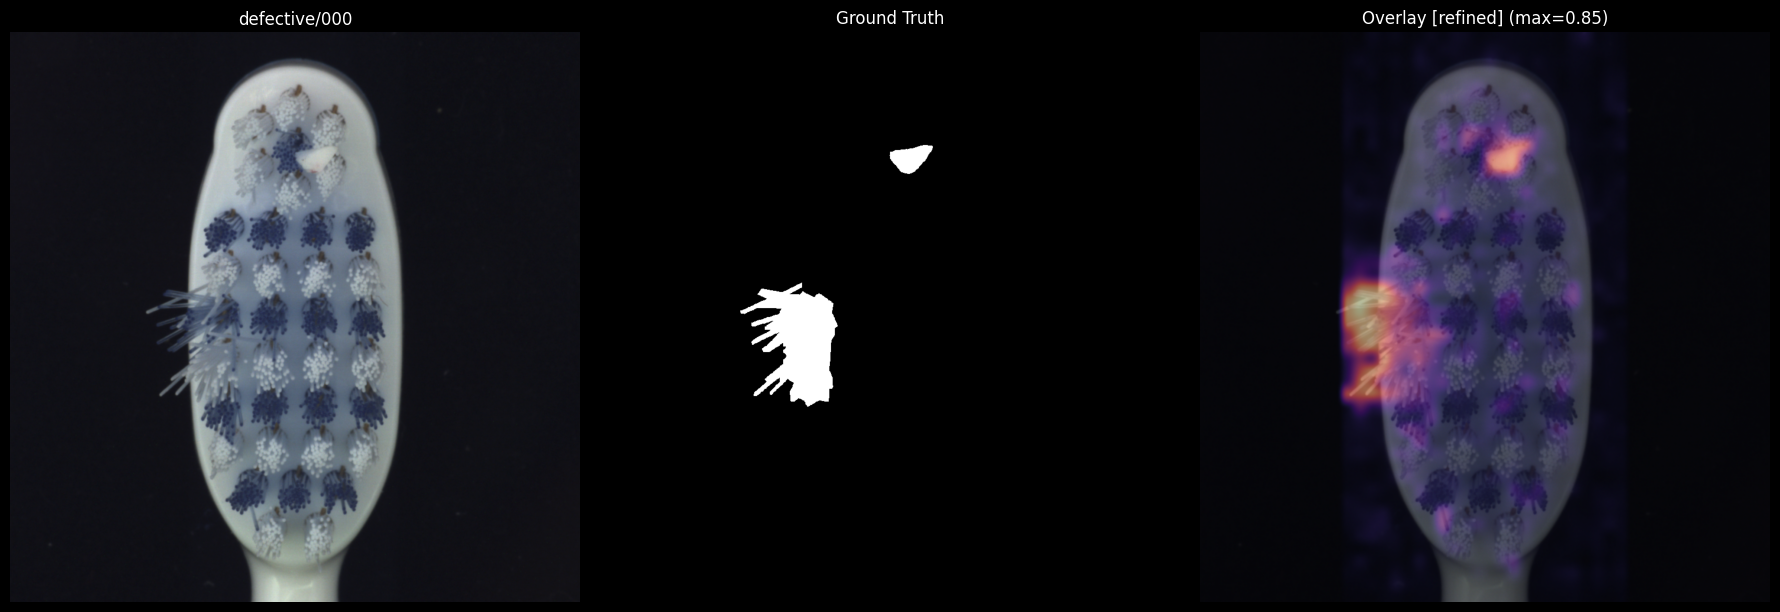

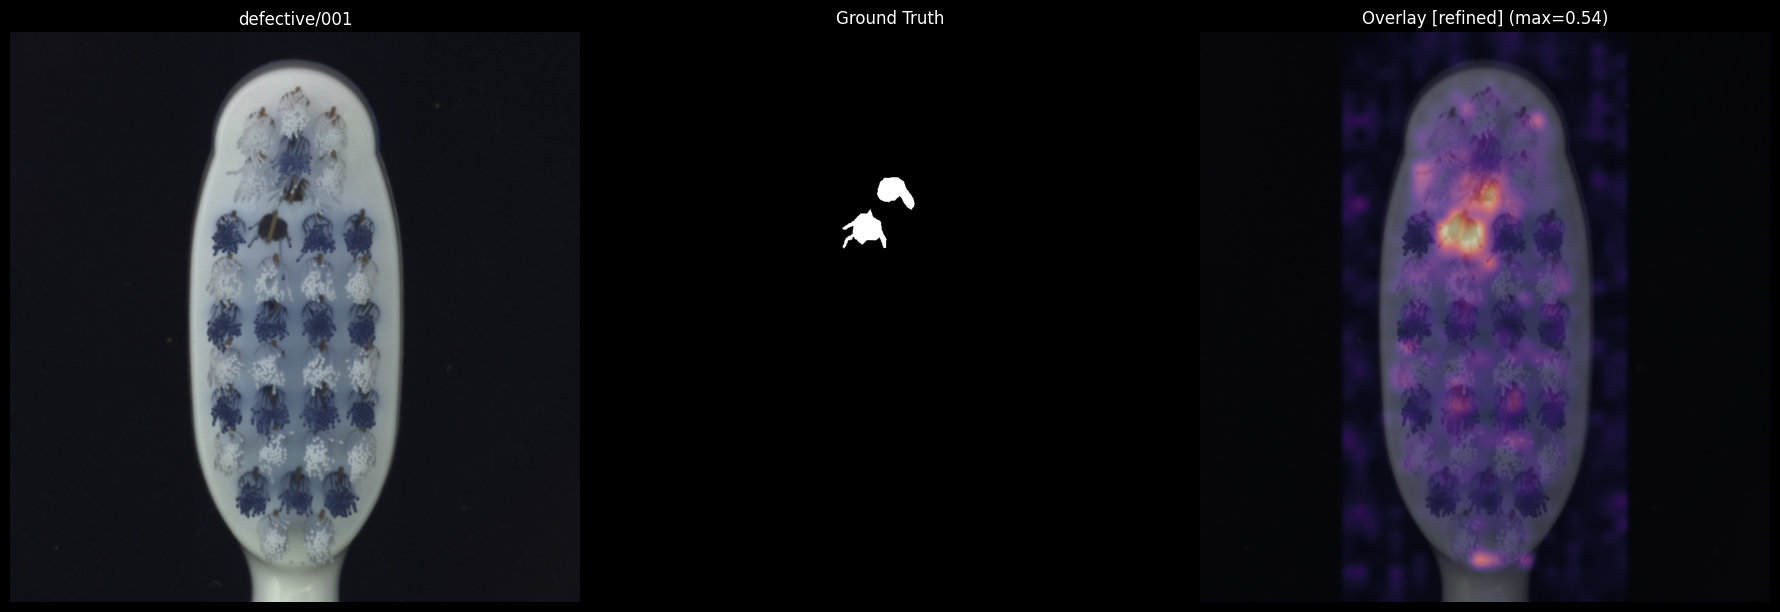

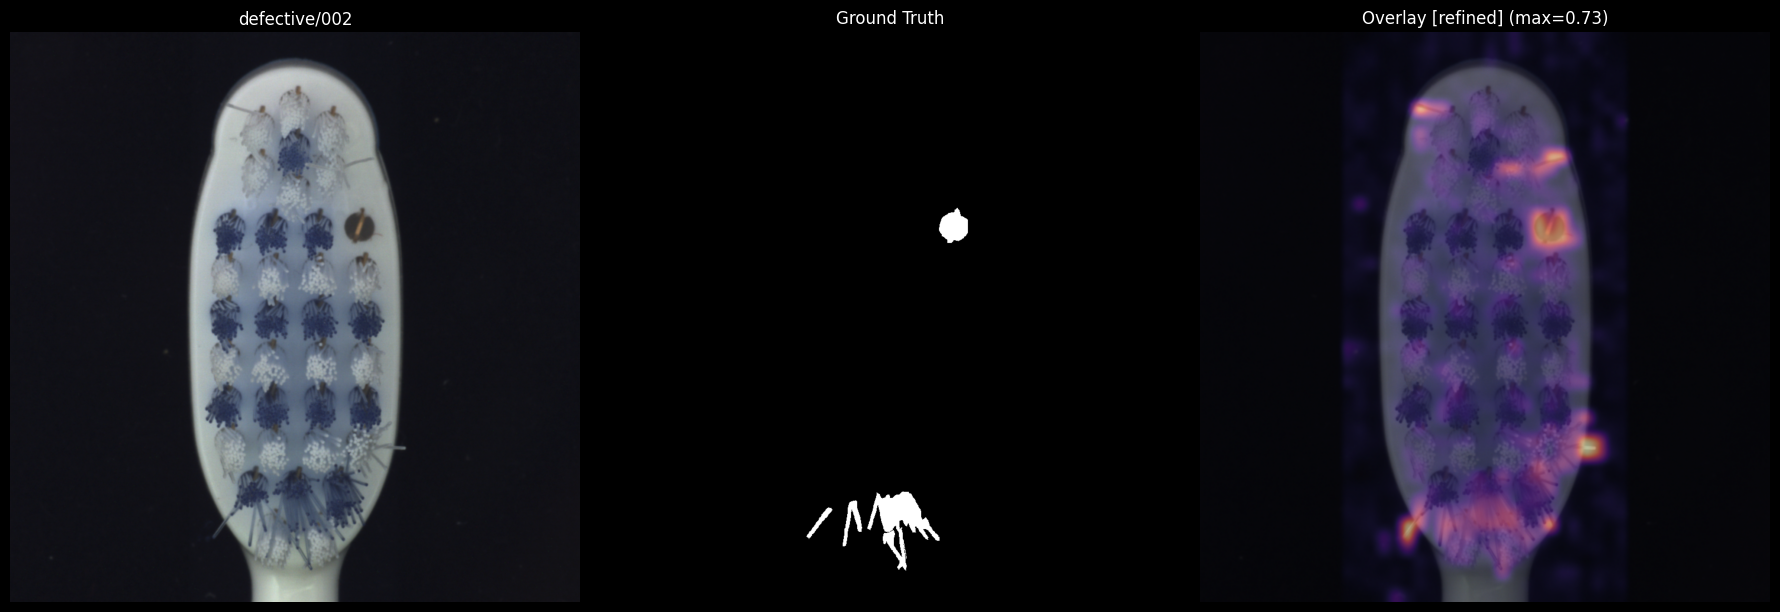

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
from pathlib import Path

project = category
artifacts_root = Path(f"artifacts/{project}")
data_root = artifacts_root / "data"
heatmaps_root = artifacts_root / "heatmaps"

# Gather anomalous test images
anomaly_images = []
for label_dir in (data_root / "test").iterdir():
    if not label_dir.is_dir() or label_dir.name == "good":
        continue
    label = label_dir.name
    for img_path in sorted(label_dir.glob("*")):
        if img_path.suffix.lower() in [".jpg", ".jpeg", ".png"]:
            stem = img_path.stem

            refined_path = heatmaps_root / "refined" / "test" / label / f"{stem}.npy"
            reverted_path = heatmaps_root / "reverted" / "test" / label / f"{stem}.npy"
            heatmap_path = refined_path if refined_path.exists() else reverted_path

            anomaly_images.append({
                "stem": stem,
                "label": label,
                "image": img_path,
                "gt": data_root / "ground_truth" / label / f"{stem}.png",
                "heatmap": heatmap_path,
                "is_refined": refined_path.exists(),
            })

n_refined = sum(1 for x in anomaly_images if x["is_refined"])
print(f"Found {len(anomaly_images)} anomalous test images ({n_refined} refined, {len(anomaly_images) - n_refined} reverted)")
print()


for i, entry in enumerate(anomaly_images):
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    img = cv2.imread(str(entry["image"]))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    gt = cv2.imread(str(entry["gt"]), cv2.IMREAD_GRAYSCALE) if entry["gt"].exists() else None
    heatmap = np.load(entry["heatmap"]) if entry["heatmap"].exists() else None

    # Original
    axes[0].imshow(img_rgb)
    axes[0].set_title(f"{entry['label']}/{entry['stem']}")
    axes[0].axis("off")

    # Ground Truth
    if gt is not None:
        axes[1].imshow(gt, cmap="gray")
    else:
        axes[1].text(0.5, 0.5, "No GT", ha="center", va="center")
    axes[1].set_title("Ground Truth")
    axes[1].axis("off")

    # Overlay (heatmap on image)
    if heatmap is not None:
        heatmap_resized = cv2.resize(heatmap, (img_rgb.shape[1], img_rgb.shape[0]))
        denom = (heatmap_resized.max() - heatmap_resized.min()) + 1e-8
        heatmap_norm = (heatmap_resized - heatmap_resized.min()) / denom
        heatmap_color = (plt.cm.magma(heatmap_norm)[:, :, :3] * 255).astype(np.uint8)
        blended = (0.4 * img_rgb + 0.6 * heatmap_color).astype(np.uint8)
        axes[2].imshow(blended)
        source = "refined" if entry["is_refined"] else "reverted"
        axes[2].set_title(f"Overlay [{source}] (max={heatmap.max():.2f})")
    else:
        axes[2].imshow(img_rgb)
        axes[2].set_title("Overlay (no heatmap found)")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

    if i < len(anomaly_images) - 1:
        input(f"[{i+1}/{len(anomaly_images)}] Press Enter for next...")
    else:
        print("Done!")